In [ ]:
# sudo apt-get install python3-dev build-essential swig
! pip3 install ortools matplotlib --quiet --use-pep517

In [7]:
from dataclasses import dataclass
import csv

SWITCH_WIDTH = 14.6
KEY_RADIUS = 5

@dataclass
class Vec2:
    x: float
    y: float


def parse_dimension(text):
    if not text.endswith("mm"):
        raise ValueError("dimension should use mm")
    return float(text[:-2])


def enumerate_positions(path):
    with open(path, "rt") as f:
        for row in csv.DictReader(f):
            if row["Device"] == "HAL403SO":
                yield Vec2(parse_dimension(row["Ref X"]), parse_dimension(row["Ref Y"]))


positions = list(enumerate_positions("../left.csv"))
positions = [pos for pos in positions if pos.y > -200]
assert positions
print(f"Positions loaded ({len(positions)} elements)")


Positions loaded (33 elements)


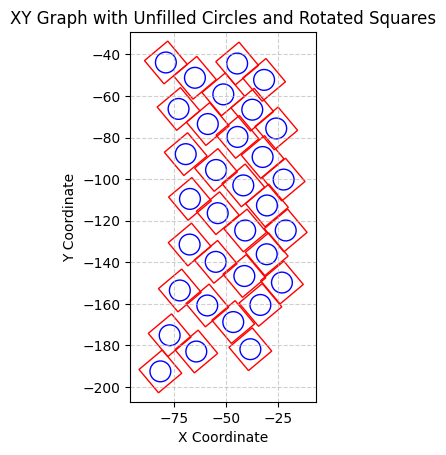

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def min_max(l, margin):
    lst = list(l)
    return min(lst) - margin, max(lst) + margin

def plot_board(positions, angle):
    # Create a fi
    # Create a figure and axis object
    fig, ax = plt.subplots()
    # Loop through the coordinates to add a circle and a square at each point
    for pos in positions:
        # Add a circle marker
        circle = patches.Circle((pos.x, pos.y), radius=KEY_RADIUS, edgecolor='blue', fill=False)
        ax.add_patch(circle)

        # Add a square marker, rotated by 40 degrees
        # Calculate the bottom-left corner to center the square
        square = patches.Rectangle(
            (pos.x - SWITCH_WIDTH /2 , pos.y - SWITCH_WIDTH /2),
            width=SWITCH_WIDTH,
            height=SWITCH_WIDTH,
            angle=angle,
            rotation_point = "center",
            edgecolor='red',
            fill=False
        )
        ax.add_patch(square)

    # Set the aspect ratio to 'equal' to prevent distortion of shapes
    ax.set_aspect('equal', adjustable='box')

    # Set plot title and labels
    ax.set_title('XY Graph with Unfilled Circles and Rotated Squares')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')

    # Adjust the plot limits to fit all shapes with some padding
    ax.set_xlim(*min_max((pos.x for pos in positions), margin=SWITCH_WIDTH))
    ax.set_ylim(*min_max((pos.y for pos in positions), margin=SWITCH_WIDTH))

    # Add a grid for better readability
    ax.grid(True, linestyle='--', alpha=0.6)

    # Save the plot to a file
    plt.show()

plot_board(positions, 40)

In [1]:
! pip3 install pyscipopt

SCIP did not find an optimal solution.
presolving:
(round 1, exhaustive) 0 del vars, 0 del conss, 0 add conss, 1 chg bounds, 0 chg sides, 0 chg coeffs, 528 upgd conss, 0 impls, 0 clqs
   (0.1s) probing: 1000/2112 (47.3%) - 0 fixings, 0 aggregations, 999 implications, 0 bound changes
   (0.1s) probing: 1001/2112 (47.4%) - 0 fixings, 0 aggregations, 1000 implications, 0 bound changes
   (0.1s) probing aborted: 1000/1000 successive useless probings
   (0.1s) symmetry computation started: requiring (bin +, int +, cont +), (fixed: bin -, int -, cont -)
   (0.1s) no symmetry present (symcode time: 0.00)
presolving (2 rounds: 2 fast, 2 medium, 2 exhaustive):
 0 deleted vars, 0 deleted constraints, 0 added constraints, 1 tightened bounds, 0 added holes, 0 changed sides, 0 changed coefficients
 1000 implications, 0 cliques
presolved problem has 2179 variables (2112 bin, 0 int, 0 impl, 67 cont) and 2641 constraints
   2112 constraints of type <linear>
    528 constraints of type <logicor>
      

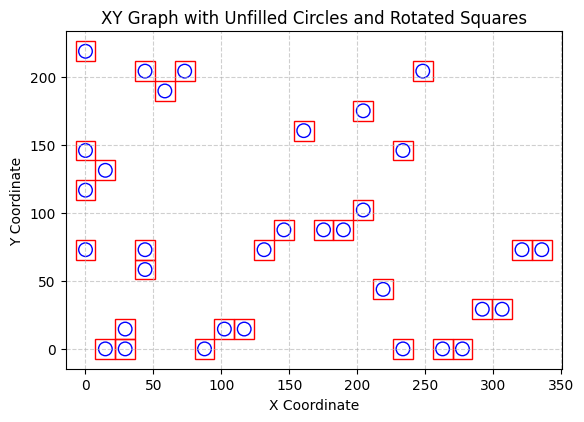

In [24]:
from pyscipopt import Model, quicksum
from pyscipopt.recipes.nonlinear import set_nonlinear_objective
import itertools
def solve_square_placement(positions, M):

    model = Model("square_placement")

    # --- 1. Define Variables ---
    squares = range(len(positions))
    # Continuous variables for the center coordinates
    x = [model.addVar(f"x_{i}", vtype="C") for i in squares]
    y = [model.addVar(f"y_{i}", vtype="C") for i in squares]

    # Binary variables for non-overlap constraints
    overlap_vars = {}
    for i, j in itertools.combinations(squares, 2):
        a_ij = model.addVar(f"a_{i}{j}", vtype="B")
        b_ij = model.addVar(f"b_{i}{j}", vtype="B")
        c_ij = model.addVar(f"c_{i}{j}", vtype="B")
        d_ij = model.addVar(f"d_{i}{j}", vtype="B")
        overlap_vars[(i, j)] = (a_ij, b_ij, c_ij, d_ij)

    # --- 2. Set Objective Function ---
    terms = quicksum([(x[i] - positions[i].x)**2 + (y[i] - positions[i].y)**2 for i in squares])
    set_nonlinear_objective(model, terms, 'minimize')

    # --- 3. Add Constraints ---
    half_side = SWITCH_WIDTH / 2
    for i, j in itertools.combinations(squares, 2):
        a_ij, b_ij, c_ij, d_ij = overlap_vars[(i, j)]

        # One non-overlap condition must be chosen
        model.addCons(a_ij + b_ij + c_ij + d_ij >= 1)

        # Positional constraints with Big M
        model.addCons(x[i] + half_side <= x[j] - half_side + M * (1 - a_ij))
        model.addCons(x[j] + half_side <= x[i] - half_side + M * (1 - b_ij))
        model.addCons(y[i] + half_side <= y[j] - half_side + M * (1 - c_ij))
        model.addCons(y[j] + half_side <= y[i] - half_side + M * (1 - d_ij))

    # --- 4. Solve and Get Results ---
    model.setRealParam('limits/time', 12.0)
    model.optimize()

    if model.getStatus() == "optimal":
        pass
    else:
        print("SCIP did not find an optimal solution.")
    solution = []
    for i in squares:
        sol_x = model.getVal(x[i])
        sol_y = model.getVal(y[i])
        solution.append(Vec2(sol_x, sol_y))
    return solution


# --- Example Usage ---
big_M = 1000.0

optimized_positions = solve_square_placement(positions, big_M)
plot_board(optimized_positions, 0)


In [4]:
# sudo apt-get install python3-dev build-essential swig
! pip3 install wheel box2d-py ipycanvas ipywidgets --quiet --use-pep517

In [37]:
import Box2D
from Box2D import b2World, b2_staticBody, b2_dynamicBody
import ipycanvas
from ipycanvas import Canvas
import time
import numpy as np

# --- Setup the Canvas ---
canvas = Canvas(width=200, height=500)
display(canvas)

# --- Setup the Box2D World ---
world = b2World(gravity=(0, 0)) # No gravity since you're using springs

# --- Define a simple cube and its destination ---
ground = world.CreateBody(position=(0, 0), type=b2_staticBody)
cubes = []

for pos in positions[:3]:
    cube = world.CreateDynamicBody(position=(pos.x, pos.y), angle =30)
    cube.CreatePolygonFixture(box=(SWITCH_WIDTH  /2, SWITCH_WIDTH/2), density=1, friction=0)
    cubes.append(cube)
    # This simulates the "relative deformation" metric
    # spring = world.CreateDistanceJoint(
    #     bodyA=cube,
    #     bodyB=ground, # The ground acts as a fixed point
    #     localAnchorA=(0, 0),
    #     localAnchorB=(pos.x, pos.y),
    #     length=0, # This will make it act like a spring pulling to the anchor, but is also discouraged.
    #     frequencyHz=5.0,
    #     dampingRatio=0.5,
    # )

def enumerate_all_pairs(items):
  n = len(items)
  for i in range(n):
    for j in range(i + 1, n):
      yield items[i], items[j]

for a, b in enumerate_all_pairs(cubes):
    spring = world.CreateDistanceJoint(
        bodyA=a,
        bodyB=b,
        localAnchorA=(0, 0),
        localAnchorB=(0, 0),
        length=(a.position - b.position).length *2,
        frequencyHz=5.0,
        dampingRatio=0.5,
    ) 

# --- Rendering Function ---
def render_world():
    with ipycanvas.hold_canvas():
        canvas.clear()
        canvas.fill_style = 'lightblue'
        canvas.stoke_style = 'black'
        for body in world.bodies:
            for fixture in body.fixtures:
                shape = fixture.shape
                vertices = [(body.transform * v) for v in shape.vertices]
                vertices = [((v[0]+100) * 2, v[1] * -2) for v in vertices]
                canvas.fill_polygon(vertices)
                canvas.stroke_polygon(vertices)
        # Draw the spring
        # canvas.stroke_style = 'red'
        # canvas.line_width = 2
        # p1 = np.array(cube_body.position) * SCALE
        # p2 = np.array(target_pos) * SCALE
        # p1_canvas = (p1[0] + canvas.width / 2, -p1[1] + canvas.height / 2)
        # p2_canvas = (p2[0] + canvas.width / 2, -p2[1] + canvas.height / 2)
        # canvas.stroke_line(p1_canvas[0], p1_canvas[1], p2_canvas[0], p2_canvas[1])

# --- Main Simulation Loop ---
time_step = 1.0 / 60.0
velocity_iterations = 6
position_iterations = 4

for i in range(200): # Run for 200 simulation steps
    for j in range(10):
        world.Step(time_step, velocity_iterations, position_iterations)
    render_world()
    canvas.stroke_line(0, i,10,i)

Canvas(width=200)